# Сбор и подготовка данных
## Эффект изменений ключевой ставки ЦБ на кредитный и депозитный рынок России

Этот ноутбук собирает все временные ряды необходимые для каузального анализа и объединяет их в единый датафрейм `df_general`.

**Источники данных:**
- API ЦБ РФ (`cbr.ru/dataservice/dataNew`) — ипотека, ставки, М2
- Сайт ЦБ РФ — ключевая ставка и инфляция (Excel)
- Статистические показатели банковского сектора ЦБ РФ — объём вкладов физлиц (Excel, листы «Пассивы - всего»)

**Итоговый период:** сентябрь 2013 — декабрь 2025, помесячно

In [3]:
import pandas as pd
import requests
from functools import reduce
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## 1. Ключевая ставка и инфляция

**Источник:** cbr.ru, раздел «Инфляция и ключевая ставка Банка России»

**Ключевая ставка** — главная переменная-причина во всех трёх каузальных вопросах. Инструмент денежно-кредитной политики ЦБ, единый для всей страны.

**Инфляция** — концептуально является конфаундером: ЦБ повышает ставку в ответ на рост инфляции, и одновременно инфляция сама влияет на поведение заёмщиков и вкладчиков. Включена в датафрейм для диагностики, но в основные модели не входит из-за мультиколлинеарности с ключевой ставкой (эмпирически подтверждено в анализе).

In [4]:
df_key_rate_and_inflation = pd.read_excel('../data/Инфляция и ключевая ставка Банка России_F17_09_2013_T15_09_2026.xlsx', dtype={'Дата': str}).iloc[::-1].reset_index(drop=True)

/Users/wicdt/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


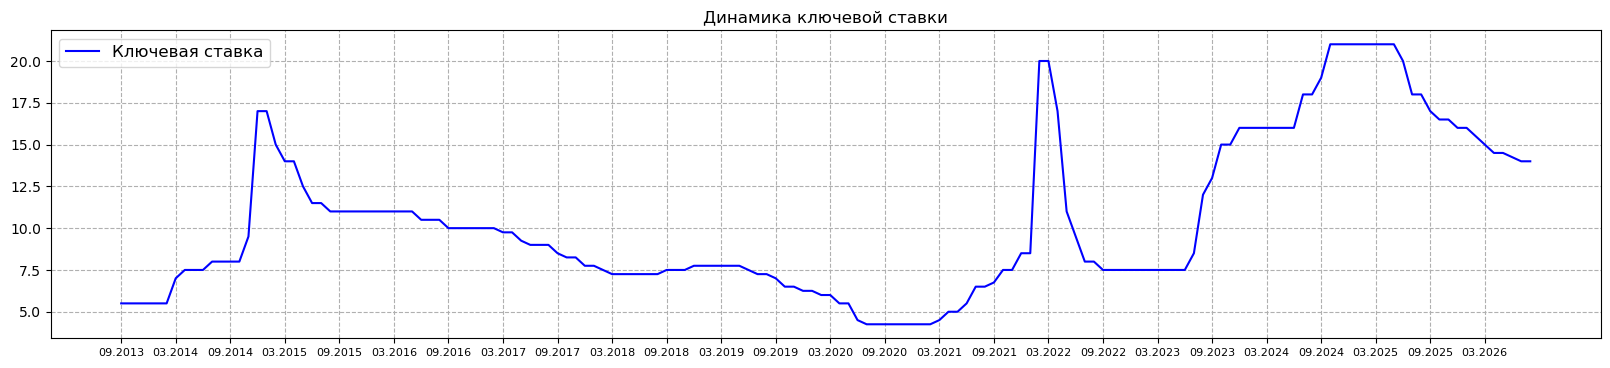

In [87]:
key_rates = df_key_rate_and_inflation['Ключевая ставка, % годовых'].tolist()
date_months = df_key_rate_and_inflation['Дата'].astype(str).tolist()
plt.figure(figsize=(20, 4))
plt.grid(True, linestyle='--')
plt.plot(date_months, key_rates, color='blue', label='Ключевая ставка')
plt.title('Динамика ключевой ставки')
plt.legend(loc='upper left', fontsize=12)
x = range(len(date_months))
plt.xticks(x[::6], date_months[::6], fontsize=8)
plt.show()

## 2. Анализ частоты изменений ключевой ставки

Перед построением моделей проверяем насколько часто менялась ставка — это определяет выбор метода анализа. Классический event study требует изолированных событий с достаточным окном до и после. Если изменения слишком частые и перекрываются — event study неприменим.

In [97]:
pauses = [0]
key_rate_prev = key_rates[0]
pause_months = 0
for key_rate in key_rates[1:]:
    if key_rate != key_rate_prev:
        pause_months = 0
        key_rate_prev = key_rate
    else:
        pause_months += 1
    pauses.append(pause_months)
df_key_rate_and_inflation['pause'] = pauses

In [98]:
df_key_rate_and_inflation['pause'].describe()

count    156.000000
mean       1.724359
std        2.207242
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max        9.000000
Name: pause, dtype: float64

<BarContainer object of 10 artists>

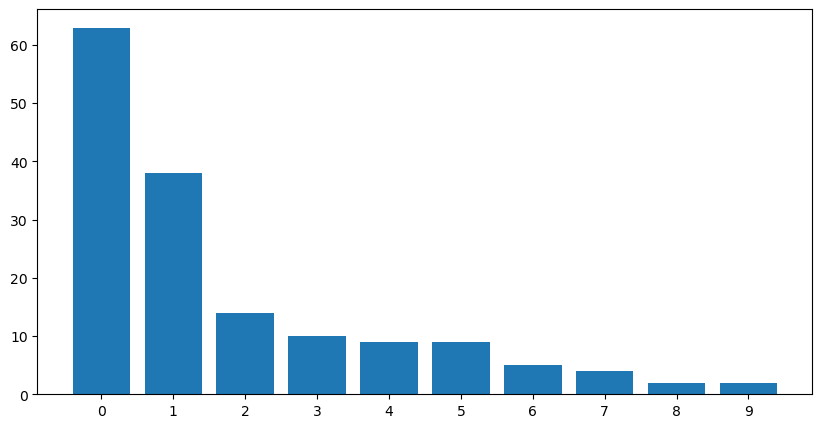

In [99]:
pause_hist = df_key_rate_and_inflation['pause'].value_counts()
plt.figure(figsize=(10, 5))
plt.xticks(range(len(pause_hist.index.tolist())), pause_hist.index.tolist())
plt.bar(pause_hist.index.tolist(), pause_hist.values.tolist())

In [100]:
min_gap = 1

clean_events = []
for i in range(len(pauses)):
    if pauses[i] != 0:
        continue
    pause_before = pauses[i-1] if i > 0 else 999
    pause_after = 0
    for j in range(i+1, min(i+min_gap+1, len(pauses))):
        if pauses[j] == 0:
            break
        pause_after += 1
    
    if pause_before >= min_gap and pause_after >= min_gap:
        clean_events.append(i)

print(f"Всего изменений: {sum(1 for p in pauses if p == 0)}")
print(f"Чистых событий (пауза >= {min_gap} мес. с обеих сторон): {len(clean_events)}")

Всего изменений: 63
Чистых событий (пауза >= 1 мес. с обеих сторон): 18


## Вывод: event study неприменим

Медиана паузы между изменениями ставки составляет 1 месяц, при фильтрации событий с паузой >= 3 месяца с обеих сторон остаётся только 1 чистое событие из 63. Это делает классический event study невозможным.

**Выбранный метод:** Local Projections (Jorda, 2005) — серия регрессий для каждого горизонта h от 0 до N месяцев. Не требует изолированных событий, позволяет оценить эффект на каждом горизонте и построить импульсный отклик.

## 3. Загрузка данных через API ЦБ РФ

API endpoint: `http://www.cbr.ru/dataservice/dataNew`

Загружаем следующие показатели:

| Индикатор | Роль в модели | Вопрос |
|---|---|---|
| Объём ипотечных кредитов (ind. 45) | Зависимая переменная | 1, 3 |
| Количество ипотечных кредитов (ind. 44) | Зависимая переменная (альтернативная) | 3 |
| Сезонно скорректированная задолженность (ind. 55) | Robustness check | 1 |
| Ставка по ипотеке (ind. 29) | Медиатор — показывает механизм передачи ключевой ставки на ипотечный рынок; в основную модель не включается чтобы не блокировать измеряемый эффект | 1 |
| Ставка по вкладам физлиц краткосрочная (ind. 37, срез до 1 года) | Медиатор — показывает скорость передачи ключевой ставки в депозитные ставки | 2 |
| Ставка по вкладам физлиц долгосрочная (ind. 37, срез 1-3 года) | Медиатор — банки медленнее транслируют ставку на длинные горизонты | 2 |
| Денежный агрегат М2 (ind. 7) | Прокси экономического цикла — контрольная переменная во всех моделях; отражает общую ликвидность в экономике | 1, 2, 3 |

Для каждого показателя выбираем срез «Российская Федерация в целом» и «в рублях».

In [11]:
response = requests.get('http://www.cbr.ru/dataservice/categoryNew')
if response.status_code != 200:
    print(f'Ошибка: {response.status_code}, {response.text}')
df_categories = pd.DataFrame(response.json()['category'])
df_categories.to_csv(f'../data/categories.csv', index=False, encoding='utf-8')
df_categories[((df_categories['category_id'] == 21) & (df_categories['indicator_id'].isin([44, 45, 55]))) |
((df_categories['category_id'] == 14) & (df_categories['indicator_id'] == 29)) |
((df_categories['category_id'] == 18) & (df_categories['indicator_id'] == 37)) |
((df_categories['category_id'] == 5) & (df_categories['indicator_id'] == 7))][[
    'category_id', 
    'category_name', 
    'indicator_id', 
    'indicator_name', 
    'begin_dt', 
    'end_dt']]

,category_id,category_name,indicator_id,indicator_name,begin_dt,end_dt
2,5,Денежно-кредитная статистика-Структура денежно...,7,Денежный агрегат М2,1992,2026
101,21,Статистика кредитования-По ипотечным жилищным ...,44,Количество кредитов,2019,2026
102,21,Статистика кредитования-По ипотечным жилищным ...,45,Объем кредитов,2019,2026
104,21,Статистика кредитования-По ипотечным жилищным ...,55,Сезонно скорректированная задолженность по кре...,2009,2026
119,18,Статистика процентных ставок-По депозитам-В це...,37,Ставки по вкладам (депозитам) физических лиц,2014,2026
128,14,Статистика процентных ставок-По кредитам-В цел...,29,Ставки по ипотечным жилищным кредитам,2017,2026


In [12]:
BASE = "http://www.cbr.ru/dataservice/dataNew"
def fetch_data(category_id, indicator_ids, y1=2013, y2=2026):
    params = {
        'categoryId': category_id,
        'y1': y1,
        'y2': y2,
        'i_ids[]': indicator_ids
    }
    response = requests.get(BASE, params=params)
    if response.status_code != 200:
        print(f'Ошибка: {response.status_code}, {response.text}')
        return None
    row_data = response.json()['RowData']
    links = response.json()['Links']
    df_data = pd.DataFrame(row_data)
    df_links = pd.DataFrame(links)
    df_data.to_csv(f'../data/cat_{category_id}_ind_{indicator_ids[0]}_{y1}_to_{y2}.csv', index=False, encoding='utf-8')
    df_links.to_csv(f'../data/links_cat_{category_id}_ind_{indicator_ids[0]}_{y1}_to_{y2}.csv', index=False, encoding='utf-8')
    return df_data, df_links

In [13]:
df_mortgage_count, df_mortgage_count_links = fetch_data(category_id=21, indicator_ids=[44])
df_mortgage_volume, df_mortgage_volume_links = fetch_data(category_id=21, indicator_ids=[45])
df_seasoned_debts, df_seasoned_debts_links = fetch_data(category_id=21, indicator_ids=[55])
df_mortgage_rate, df_mortgage_rate_links = fetch_data(category_id=14, indicator_ids=[29])
df_deposit_rate, df_deposit_rate_links = fetch_data(category_id=18, indicator_ids=[37])
df_m2, df_m2_links = fetch_data(category_id=5, indicator_ids=[7])

Для количества кредитов берем срез по всей странне и в рублях:
- measure1_id = 22
- measure2_id = 36

In [14]:
df_mortgage_count_links[df_mortgage_count_links['measure1_name'] == 'Российская Федерация'][['measure1_id', 'measure1_name', 'un_name']].drop_duplicates()

,measure1_id,measure1_name,un_name
4,22,Российская Федерация,единиц


In [15]:
df_mortgage_count_links[['measure2_id', 'measure2_name', 'un_name']].drop_duplicates()

,measure2_id,measure2_name,un_name
0,36,В рублях,единиц
2,40,В иностранной валюте,единиц
3,35,Всего,единиц


Для объема кредитов берем срез по всей странне и в рублях:
- measure1_id = 22
- measure2_id = 36

In [16]:
df_mortgage_volume_links[df_mortgage_volume_links['measure1_name'] == 'Российская Федерация'][['measure1_id', 'measure1_name', 'un_name']].drop_duplicates()

,measure1_id,measure1_name,un_name
58,22,Российская Федерация,млн руб.


In [17]:
df_mortgage_volume_links[['measure2_id', 'measure2_name', 'un_name']].drop_duplicates()

,measure2_id,measure2_name,un_name
0,36,В рублях,млн руб.
1,35,Всего,млн руб.
2,40,В иностранной валюте,млн руб.


Для сезонно скoректированной задолженности берем в рублях:
- measure1_id = нет
- measure2_id = 36

In [18]:
df_seasoned_debts_links[['measure1_id', 'measure1_name', 'un_name']].drop_duplicates()

,measure1_id,measure1_name,un_name
0,None,None,млн руб.


In [19]:
df_seasoned_debts_links[['measure2_id', 'measure2_name', 'un_name']].drop_duplicates()

,measure2_id,measure2_name,un_name
0,36,В рублях,млн руб.
1,35,Всего,млн руб.


Для ставки по ипотечным жилищным кредитам берем срез в рублях:
- measure1_id = нет
- measure2_id = 36

In [20]:
df_mortgage_rate_links[['measure1_id', 'measure1_name', 'un_name']].drop_duplicates()

,measure1_id,measure1_name,un_name
0,None,None,% годовых


In [21]:
df_mortgage_rate_links[['measure2_id', 'measure2_name', 'un_name']].drop_duplicates()

,measure2_id,measure2_name,un_name
0,36,В рублях,% годовых
1,40,В иностранной валюте,% годовых


Для процента по вкладам берем срез в рублях:
- measure1_id = 2
- measure2_id = 6 и 9 для разных регрессий

Краткосрочные вклады «От 181 дня до 1 года» (id: 6) и долгосрочные вклады «От 1 года до 3 лет» (id: 9)

In [22]:
df_deposit_rate_links[['measure1_id', 'measure1_name', 'un_name']].drop_duplicates()

,measure1_id,measure1_name,un_name
0,2,В рублях,% годовых
2,4,В евро,% годовых
5,3,В долларах США,% годовых


In [23]:
df_deposit_rate_links[['measure2_id', 'measure2_name', 'un_name']].drop_duplicates()

,measure2_id,measure2_name,un_name
0,9,От 1 года до 3 лет,% годовых
1,3,"До 30 дней, кроме ''до востребования''",% годовых
2,10,Свыше 3 лет,% годовых
3,7,"До 1 года, включая ''до востребования''",% годовых
4,4,От 31 до 90 дней,% годовых
5,11,Свыше 1 года,% годовых
6,1,"""До востребования""",% годовых
7,5,От 91 до 180 дней,% годовых
8,8,"До 1 года, кроме ''до востребования''",% годовых
9,2,"До 30 дней, включая ''до востребования''",% годовых


Для агрегата М2 берем срез всего:
- measure1_id = нет
- measure2_id = 12

In [24]:
df_m2_links[['measure1_id', 'measure1_name', 'un_name']].drop_duplicates()

,measure1_id,measure1_name,un_name
0,None,None,млрд руб.


In [25]:
df_m2_links[['measure2_id', 'measure2_name', 'un_name']].drop_duplicates()

,measure2_id,measure2_name,un_name
0,12,Всего,млрд руб.
1,19,Денежный агрегат М1,млрд руб.
2,20,Другие депозиты других финансовых организаций,млрд руб.
3,21,Другие депозиты нефинансовых организаций,млрд руб.
4,22,Другие депозиты домашних хозяйств,млрд руб.


In [26]:
df_m2.head()

,id,indicator_id,measure1_id,measure2_id,unit_id,obs_val,date,periodicity
0,8474342,7,None,12,3,27593.4,2013-06-01T00:00:00,month
1,8475106,7,None,12,3,33935.0,2016-02-01T00:00:00,month
2,8478295,7,None,12,3,44254.0,2018-10-01T00:00:00,month
3,8475690,7,None,12,3,59194.1,2021-06-01T00:00:00,month
4,8478900,7,None,12,3,97816.7,2024-02-01T00:00:00,month


In [27]:
df_key_rate_and_inflation.iloc[50:70]

,Дата,"Ключевая ставка, % годовых","Инфляция, % г/г",Цель по инфляции,Пауза
50,11.2017,8.25,2.5,4.0,1
51,12.2017,7.75,2.5,4.0,0
52,01.2018,7.75,2.2,4.0,1
53,02.2018,7.50,2.2,4.0,0
54,03.2018,7.25,2.4,4.0,0
55,04.2018,7.25,2.4,4.0,1
56,05.2018,7.25,2.4,4.0,2
57,06.2018,7.25,2.3,4.0,3
58,07.2018,7.25,2.5,4.0,4
59,08.2018,7.25,3.1,4.0,5


In [107]:
df_key_rate_and_inflation = df_key_rate_and_inflation.rename(columns={'Дата': 'date_formated', 'Ключевая ставка, % годовых': 'key_rate', 'Инфляция, % г/г': 'inflation'})
df_key_rate_and_inflation['date_formated'] = df_key_rate_and_inflation['date_formated'].str.lstrip('0')
df_mortgage_count['date_formated'] = pd.to_datetime(df_mortgage_count['date']).dt.strftime('%m.%Y').str.lstrip('0')
df_mortgage_volume['date_formated'] = pd.to_datetime(df_mortgage_volume['date']).dt.strftime('%m.%Y').str.lstrip('0')
df_seasoned_debts['date_formated'] = pd.to_datetime(df_seasoned_debts['date']).dt.strftime('%m.%Y').str.lstrip('0')
df_mortgage_rate['date_formated'] = pd.to_datetime(df_mortgage_rate['date']).dt.strftime('%m.%Y').str.lstrip('0')
df_deposit_rate['date_formated'] = pd.to_datetime(df_deposit_rate['date']).dt.strftime('%m.%Y').str.lstrip('0')
df_m2['date_formated'] = pd.to_datetime(df_m2['date']).dt.strftime('%m.%Y').str.lstrip('0')

df_key_rate_and_inflation_cleared = df_key_rate_and_inflation[['date_formated', 'key_rate', 'inflaton']]
df_mortgage_count_cleared = df_mortgage_count[(df_mortgage_count['measure1_id'] == 22) & (df_mortgage_count['measure2_id'] == 36)][['date_formated', 'obs_val']].rename(columns={'obs_val': 'mortgage_count'})
df_mortgage_volume_cleared = df_mortgage_volume[(df_mortgage_volume['measure1_id'] == 22) & (df_mortgage_volume['measure2_id'] == 36)][['date_formated', 'obs_val']].rename(columns={'obs_val': 'mortgage_volume'})
df_seasoned_debts_cleared = df_seasoned_debts[df_seasoned_debts['measure2_id'] == 36][['date_formated', 'obs_val']].rename(columns={'obs_val': 'seasoned_debts'})
df_mortgage_rate_cleared = df_mortgage_rate[df_mortgage_rate['measure2_id'] == 36][['date_formated', 'obs_val']].rename(columns={'obs_val': 'mortgage_rate'})
df_short_term_deposit_rate_cleared = df_deposit_rate[(df_deposit_rate['measure1_id'] == 2) & (df_deposit_rate['measure2_id'] == 6)][['date_formated', 'obs_val']].rename(columns={'obs_val': 'short_term_deposit_rate'})
df_long_term_deposit_rate_cleared = df_deposit_rate[(df_deposit_rate['measure1_id'] == 2) & (df_deposit_rate['measure2_id'] == 9)][['date_formated', 'obs_val']].rename(columns={'obs_val': 'long_term_deposit_rate'})
df_m2_cleared = df_m2[df_m2['measure2_id'] == 12][['date_formated', 'obs_val']].rename(columns={'obs_val': 'm2'})

## 4. Загрузка объёма вкладов физлиц из статистики банковского сектора

**Источник:** «Статистические показатели банковского сектора Российской Федерации», ЦБ РФ, лист «Пассивы - всего»

Объём вкладов физлиц — **зависимая переменная вопроса 2**. Отражает совокупные средства населения в банковской системе.

Данные разбиты на два файла с разной методологией:
- До января 2024: строка 3.3 «Физические лица» не включает начисленные проценты
- После января 2024: начисленные проценты включены в строку

Для устранения методологического разрыва из данных после 2024 вычтены начисленные проценты.

Из пассивов извлекаем три ряда:
- `total_funds_of_ind` — все средства физлиц (строка 3.3), **основная зависимая переменная**
- `time_deposits_of_ind` — срочные депозиты (строка 3.3.1), **дополнительный исход** для анализа механизма перекладывания
- `curr_accounts_of_ind` — текущие счета (строка 3.3.2), **дополнительный исход** — ожидаем падение при росте ставки так как люди переносят деньги на срочные депозиты

#### Пассивы до января 2024

In [31]:
xl = pd.ExcelFile('../data/obs_tabl20c_do_20240101.xlsx')
print(xl.sheet_names)

['Активы - всего', 'Активы - в рублях', 'Активы - в иностранной валюте', 'Активы - в ин. валюте $', 'Пассивы - всего', 'Пассивы - в рублях', 'Пассивы - в иностранной валюте', 'Пассивы - в ин.валюте $', 'Кредиты - всего', 'Кредиты - в рублях', 'Кредиты - в валюте', 'Корпоративные кредиты по срокам', 'Кредиты физ.лицам по срокам']


In [33]:
df_pass = pd.read_excel('../data/obs_tabl20c_do_20240101.xlsx', sheet_name='Пассивы - всего')
df_pass.iloc[:, :2]

,"Структура обязательств и капитала кредитных организаций, сгруппированных по источникам средств (Таблица сборника ""Статистические показатели банковского сектора Российской Федерации"" (до 1.11.2020 - ""Обзор банковского сектора Российской Федерации""), млрд руб.)",Unnamed: 1
0,NaN,Обязательства и капитал - в рублях и иностран...
1,Обязательства,NaN
2,1.,Кредиты от Банка России
3,2,Средства банков
4,2.1.,Корреспондентские счета
5,2.2.,"Кредиты, депозиты и прочие привлеченные средства"
6,2.3.,Прочие счета
7,3.,Средства клиентов
8,3.1.,Средства корпоративных клиентов1
9,3.1.1.,Депозиты и прочие привлеченные средства


In [34]:
df_pass_before_2024 = pd.read_excel('../data/obs_tabl20c_do_20240101.xlsx', sheet_name='Пассивы - всего', header=None)
for i, val in enumerate(df_pass_before_2024.iloc[:, 1]):
    if isinstance(val, str) and 'Физические лица' in val:
        print(i, val)
    if isinstance(val, str) and 'Депозиты и прочие' in val:
        print(i, val)
    if isinstance(val, str) and 'Средства на счетах' in val:
        print(i, val)

10 Депозиты и прочие привлеченные средства
11 Средства на счетах
13 Депозиты и прочие привлеченные средства
14 Средства на счетах
15 Физические лица
16 Депозиты и прочие привлеченные средства
17 Средства на счетах


In [35]:
df_pass_before_2024.iloc[[10, 11, 13, 14, 15, 16, 17], :4]

,0,1,2,3
10,3.1.1.,Депозиты и прочие привлеченные средства,3138.224206,3300.07295
11,3.1.2.,Средства на счетах,3236.546068,3227.963369
13,3.2.1.,Депозиты и прочие привлеченные средства,311.846911,283.631123
14,3.2.2.,Средства на счетах,64.341123,55.937284
15,3.3.,Физические лица,5126.196259,5224.541973
16,3.3.1.,Депозиты и прочие привлеченные средства,4428.147763,4496.276937
17,3.3.2.,Средства на счетах,698.048496,728.265036


| Номер строки | Номер | Заголовок | Что это | Нужно ли |
|:---:|:---:|:---:|:---:|:---:|
|10|3.1.1.|Депозиты и прочие привлеченные средства| Срочные вклады **корпораций** | - |
|11|3.1.2.|Средства на счетах| Текущие счета **корпораций** | - |
|13|3.2.1.|Депозиты и прочие привлеченные средства| Срочные вклады **государства** | - |
|14|3.2.2.|Средства на счетах| Текущие счета **государства** | - |
|15|3.3.|Физические лица| Все средства физлиц (сумма 16+17) | основной ряд |
|16|3.3.1.|Депозиты и прочие привлеченные средства| Срочные вклады **физлиц** | дополнительно |
|17|3.3.2.|Средства на счетах| Текущие счета **физлиц** | дополнительно |

In [91]:
df_pass_cleared_before_2024 = df_pass_before_2024.iloc[[1, 15, 16, 17], :].T
df_pass_cleared_before_2024 = df_pass_cleared_before_2024.rename(columns={1: 'date', 15: 'total_funds_of_ind', 16: 'time_deposits_of_ind', 17: 'curr_accounts_of_ind'})
df_pass_cleared_before_2024 = df_pass_cleared_before_2024.iloc[2:, :].reset_index().iloc[:, 1:]
df_pass_cleared_before_2024['date_formated'] = pd.to_datetime(df_pass_cleared_before_2024['date']).dt.strftime('%m.%Y').str.lstrip('0')
df_pass_cleared_before_2024 = df_pass_cleared_before_2024[['date_formated', 'total_funds_of_ind', 'time_deposits_of_ind', 'curr_accounts_of_ind']]

In [37]:
df_pass_cleared_before_2024.head()

,date_formated,total_funds_of_ind,time_deposits_of_ind,curr_accounts_of_ind
0,2.2008,5126.196259,4428.147763,698.048496
1,3.2008,5224.541973,4496.276937,728.265036
2,4.2008,5313.642911,4579.832136,733.810775
3,5.2008,5479.674688,4687.209589,792.465099
4,6.2008,5654.243565,4843.196077,811.047488


#### Пассивы после января 2024

In [38]:
xl = pd.ExcelFile('../data/obs_tabl20с.xlsx')
print(xl.sheet_names)

['Активы - всего', 'Активы - рубли', 'Активы - валюта', 'Активы - в ин. валюте $', 'Пассивы - всего', 'Пассивы - рубли', 'Пассивы - валюта', 'Пассивы - в ин. валюте $', 'Корпоративные кредиты по срокам', 'Кредиты физ.лицам по срокам']


In [39]:
df_pass_after_2024 = pd.read_excel('../data/obs_tabl20с.xlsx', sheet_name='Пассивы - всего')
df_pass_after_2024.iloc[:, :4]

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Структура обязательств и капитала кредитных ор...,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,№ п.п.,Показатель (млрд руб.),2016-02-01 00:00:00
3,NaN,Обязательства всего,NaN,NaN
4,NaN,1,Кредиты от Банка России,4619.325237
...,...,...,...,...
78,NaN,Итого обязательства и капитал,NaN,78281.635252
79,NaN,NaN,NaN,NaN
80,NaN,Справочно: прибыль текущего года до налогообло...,NaN,32.189078
81,NaN,NaN,NaN,NaN


In [40]:
df_pass_after_2024 = pd.read_excel('../data/obs_tabl20с.xlsx', sheet_name='Пассивы - всего', header=None)
for i, val in enumerate(df_pass_after_2024.iloc[:, 2]):
    if isinstance(val, str) and 'Средства физических лиц' in val:
        print(i, val)
    if isinstance(val, str) and 'Депозиты и прочие' in val:
        print(i, val)
    if isinstance(val, str) and 'Средства на счетах' in val:
        print(i, val)

19 Депозиты и прочие привлеченные средства
20 Депозиты и прочие привлеченные средства до переоценки
25 Средства на счетах
28 Депозиты и прочие привлеченные средства
30 Средства физических лиц
31 Депозиты и прочие привлеченные средства
35 Средства на счетах


In [41]:
df_pass_after_2024.iloc[[19, 20, 25, 28, 30, 31, 35, 36], :4]

,0,1,2,3
19,NaN,4.1.1,Депозиты и прочие привлеченные средства,12492.272633
20,NaN,4.1.1.1,Депозиты и прочие привлеченные средства до пер...,12492.272633
25,NaN,4.1.2,Средства на счетах,9913.299692
28,NaN,NaN,Депозиты и прочие привлеченные средства,42.948336
30,NaN,4.2,Средства физических лиц,22960.9696
31,NaN,4.2.1,Депозиты и прочие привлеченные средства,19757.060905
35,NaN,4.2.2,Средства на счетах,3044.179953
36,NaN,4.2.3,Начисленные проценты,159.728742


In [42]:
df_pass_after_2024.head()

,0,1,2,3,4,5,6,7,8,9,...,120,121,122,123,124,125,126,127,128,129
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Структура обязательств и капитала кредитных ор...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,№ п.п.,Показатель (млрд руб.),2016-02-01 00:00:00,2016-03-01 00:00:00,2016-04-01 00:00:00,2016-05-01 00:00:00,2016-06-01 00:00:00,2016-07-01 00:00:00,2016-08-01 00:00:00,...,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00,2026-05-01 00:00:00,2026-06-01 00:00:00,2026-07-01 00:00:00,2026-08-01 00:00:00
4,NaN,Обязательства всего,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


| Номер строки | Номер | Заголовок | Что это | Нужно ли |
|:---:|:---:|:---:|:---:|:---:|
|19|4.1.1|Депозиты и прочие привлеченные средства| Срочные вклады **корпораций** | - |
|20|4.1.1.1|Депозиты и прочие привлеченные средства до переоценки| Срочные вклады **корпораций** до переоценки | - |
|25|4.1.2|Средства на счетах| Текущие счета **корпораций** | - |
|28|NaN|Депозиты и прочие привлеченные средства| Начисленные проценты на срочные вклады **корпораций** | - |
|30|4.2|Средства физических лиц	| Все средства физлиц (сумма 31+35+36) | основной ряд, но нужно вычесть 36, т.к. данных по 36 до 2024 нет |
|31|4.2.1|Депозиты и прочие привлеченные средства| Срочные вклады **физлиц** | дополнительно |
|35|4.2.2|Средства на счетах| Текущие счета **физлиц** | дополнительно |
|36|4.2.3|Начисленные проценты| Начисленные проценты на срочные вклады **физлиц** | нужно вычесть из 30 |

In [92]:
df_pass_cleared_after_2024 = df_pass_after_2024.iloc[[3, 30, 31, 35, 36], :].T
df_pass_cleared_after_2024 = df_pass_cleared_after_2024.rename(columns={3: 'date', 30: 'total_funds_of_ind', 31: 'time_deposits_of_ind', 35: 'curr_accounts_of_ind', 36: 'accrued_interest_of_ind'})
df_pass_cleared_after_2024 = df_pass_cleared_after_2024.iloc[3:, :].reset_index().iloc[:, 1:]
df_pass_cleared_after_2024['date_formated'] = pd.to_datetime(df_pass_cleared_after_2024['date']).dt.strftime('%m.%Y').str.lstrip('0')
df_pass_cleared_after_2024['total_funds_of_ind'] -= df_pass_cleared_after_2024['accrued_interest_of_ind']
df_pass_cleared_after_2024 = df_pass_cleared_after_2024[['date_formated', 'total_funds_of_ind', 'time_deposits_of_ind', 'curr_accounts_of_ind']].iloc[96:, :]

In [93]:
df_pass_cleared = pd.concat([df_pass_cleared_before_2024, df_pass_cleared_after_2024], ignore_index=True)

## 5. Сборка итогового датафрейма

Объединяем все ряды по колонке `date_formated` (формат `М.ГГГГ`).

**Дамми-переменные:**
- `month` — номер месяца (1-12), контроль сезонности во всех моделях
- `shock_2014` — декабрь 2014, экстремальное повышение ставки до 17% за одну ночь
- `subsidized_mortgage` — апрель 2020 — июль 2023, период льготной ипотеки; в этот период государство субсидировало ставку для заёмщиков, что разорвало стандартный механизм передачи ключевой ставки на ипотечный рынок
- `shock_2022` — февраль-май 2022, санкционный шок

**Неучтённые конфаундеры** (недоступны в помесячном разрезе или впринципе неизмеримы):
- Реальные располагаемые доходы населения — только квартальные данные (Росстат)
- Цены на жильё — только квартальные данные (Росстат); частично медиатор, частично конфаундер
- Ожидания населения — не измеримы напрямую

In [113]:
dfs = [df_key_rate_and_inflation_cleared,
      df_mortgage_count_cleared,
      df_mortgage_volume_cleared,
      df_seasoned_debts_cleared,
      df_mortgage_rate_cleared,
      df_short_term_deposit_rate_cleared,
      df_long_term_deposit_rate_cleared,
      df_m2_cleared,
      df_pass_cleared]
df_general = reduce(
    lambda left, right: pd.merge(left, right, on='date_formated', how='left'), 
    dfs
)

In [116]:
df_general['month'] = df_general['date_formated'].str.split('.').str[0]
# Шок декабрь 2014 — экстремальное одноразовое повышение ставки до 17%
df_general['shock_2014'] = (df_general['date_formated'].isin(['12.2014', '1.2015', '2.2015', '3.2015'])).astype(int)

# Льготная ипотека — государство субсидировало ставку, 4.2020-6.2023
subsidized_mortgage_start = df_general[df_general['date_formated'] == '4.2020'].index[0]
df_general['subsidized_mortgage'] = (
    (df_general.index >= subsidized_mortgage_start) &
    (df_general.index <= subsidized_mortgage_start + 38)
).astype(int)

# Шок февраль-март 2022
shock_2022_start = df_general[df_general['date_formated'] == '2.2022'].index[0]
df_general['shock_2022'] = (
    (df_general.index >= shock_2022_start) & 
    (df_general.index <= shock_2022_start + 3)
).astype(int)

In [120]:
df_general.to_csv('../data/general.csv')
df_general.head()

,date_formated,key_rate,inflation,mortgage_count,mortgage_volume,seasoned_debts,mortgage_rate,short_term_deposit_rate,long_term_deposit_rate,m2,total_funds_of_ind,time_deposits_of_ind,curr_accounts_of_ind,month,shock_2014,subsidized_mortgage,shock_2022
0,9.2013,5.5,6.14,NaN,NaN,2279620.0,NaN,NaN,NaN,28499.9,15945.652852,13515.366534,2430.286318,9,0,0,0
1,10.2013,5.5,6.27,NaN,NaN,2284117.0,NaN,NaN,NaN,28352.6,15945.713302,13556.636282,2389.07702,10,0,0,0
2,11.2013,5.5,6.50,NaN,NaN,2360275.0,NaN,NaN,NaN,28276.4,16062.065195,13706.670941,2355.394254,11,0,0,0
3,12.2013,5.5,6.47,NaN,NaN,2428127.0,NaN,NaN,NaN,28873.3,16260.794307,13832.959743,2427.834564,12,0,0,0
4,1.2014,5.5,6.07,NaN,NaN,2498806.0,NaN,NaN,NaN,31155.6,16957.531046,14034.007723,2923.523323,1,0,0,0


## 6. Обзорная визуализация

Три графика для первичного анализа данных:
1. Ключевая ставка и инфляция — визуальная проверка обратной причинности
2. Ключевая ставка, ставка по ипотеке и объём выдач — предварительная картина по вопросу 1
3. Ключевая ставка, ставка по вкладам и объём вкладов — предварительная картина по вопросу 2

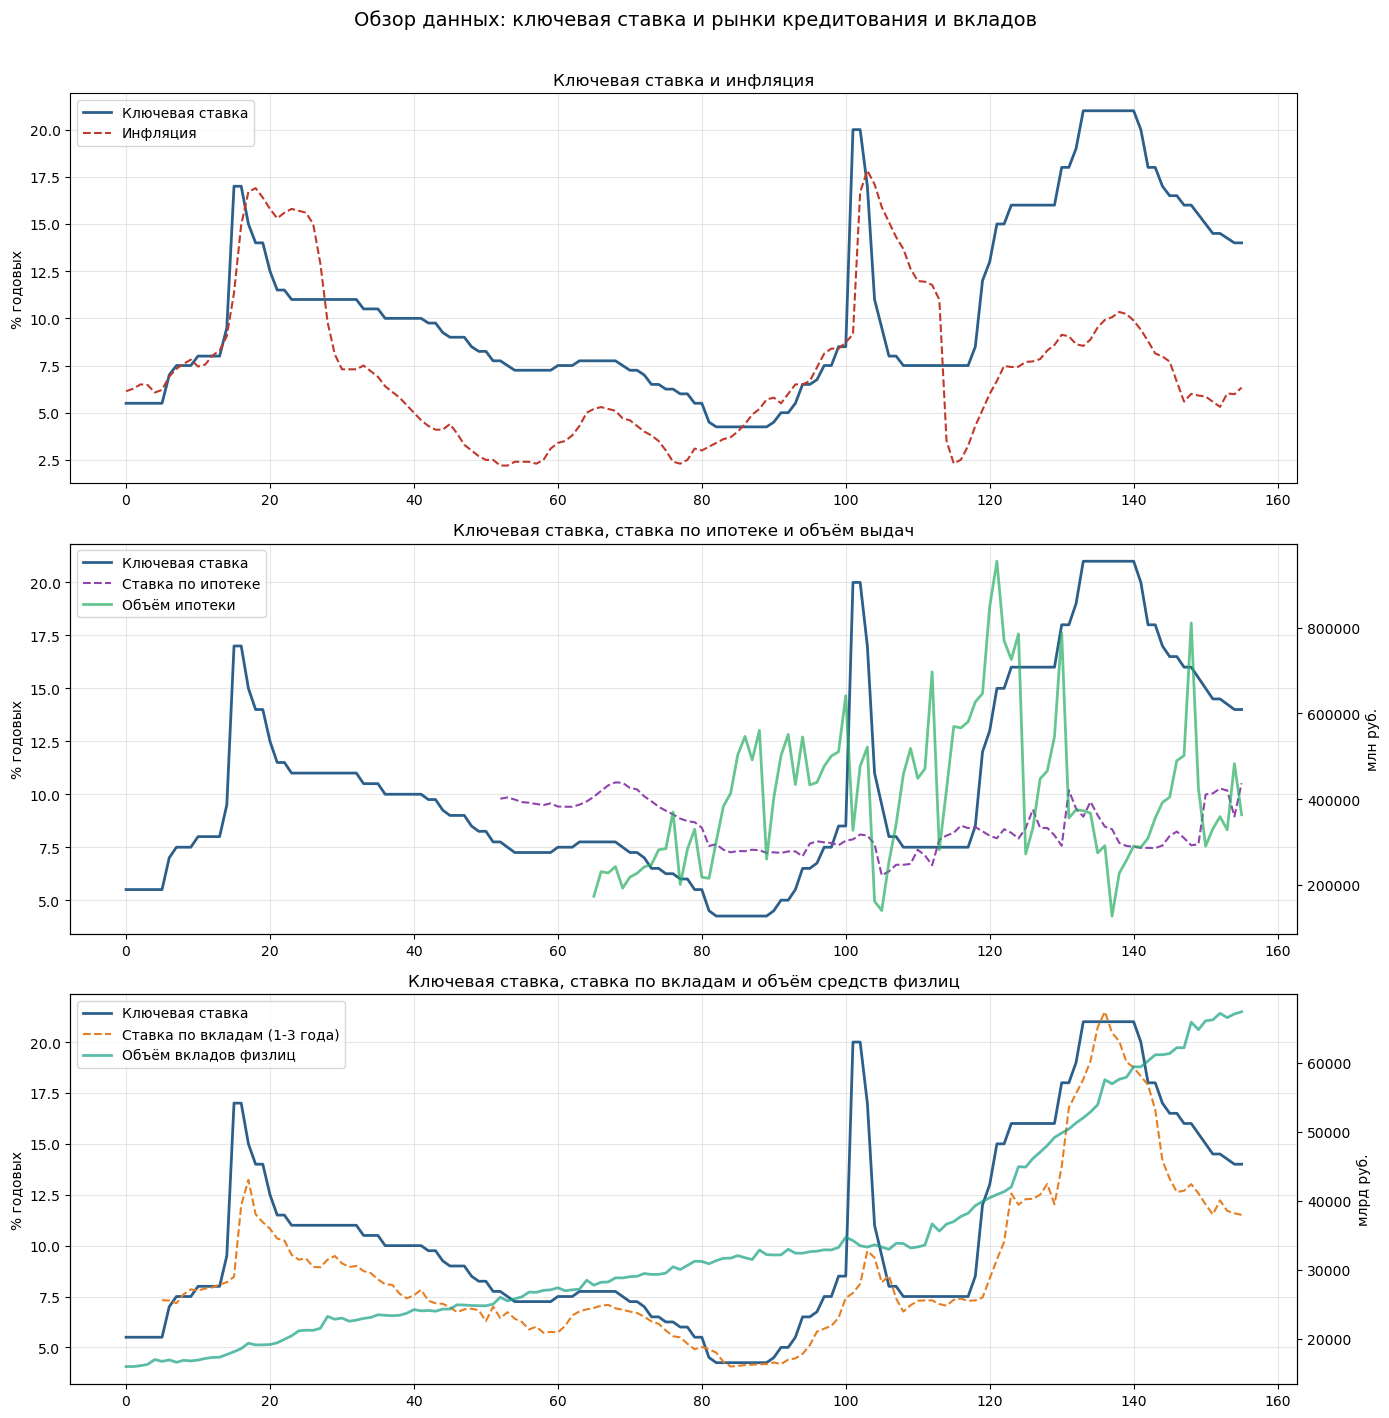

In [52]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Обзор данных: ключевая ставка и рынки кредитования и вкладов', 
             fontsize=14, y=1.01)

# Ключевая ставка и инфляция
ax1 = axes[0]
ax1.plot(df_general.index, df_general['key_rate'], 
         color='#2c5f8a', linewidth=2, label='Ключевая ставка')
ax1.plot(df_general.index, df_general['inflation'], 
         color='#c0392b', linewidth=1.5, linestyle='--', label='Инфляция')
ax1.set_title('Ключевая ставка и инфляция')
ax1.set_ylabel('% годовых')
ax1.legend()
ax1.grid(alpha=0.3)

# Ипотека
ax2 = axes[1]
ax2_twin = ax2.twinx()

df_mortgage = df_general[df_general['mortgage_volume'].notna()]

ax2.plot(df_general.index, df_general['key_rate'],
         color='#2c5f8a', linewidth=2, label='Ключевая ставка')
ax2.plot(df_general.index, df_general['mortgage_rate'],
         color='#8e44ad', linewidth=1.5, linestyle='--', label='Ставка по ипотеке')
ax2_twin.plot(df_mortgage.index, df_mortgage['mortgage_volume'],
              color='#27ae60', linewidth=2, alpha=0.7, label='Объём ипотеки')

ax2.set_title('Ключевая ставка, ставка по ипотеке и объём выдач')
ax2.set_ylabel('% годовых')
ax2_twin.set_ylabel('млн руб.')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax2.grid(alpha=0.3)

# Вклады
ax3 = axes[2]
ax3_twin = ax3.twinx()

ax3.plot(df_general.index, df_general['key_rate'],
         color='#2c5f8a', linewidth=2, label='Ключевая ставка')
ax3.plot(df_general.index, df_general['long_term_deposit_rate'],
         color='#e67e22', linewidth=1.5, linestyle='--', label='Ставка по вкладам (1-3 года)')
ax3_twin.plot(df_general.index, df_general['total_funds_of_ind'],
              color='#16a085', linewidth=2, alpha=0.7, label='Объём вкладов физлиц')

ax3.set_title('Ключевая ставка, ставка по вкладам и объём средств физлиц')
ax3.set_ylabel('% годовых')
ax3_twin.set_ylabel('млрд руб.')
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper left')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overview.png', dpi=150, bbox_inches='tight')
plt.show()